# **Import Libraries**

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix)
print("Everything is Loaded boss")

Everything is Loaded boss


# **Data exploration**

## **Load The Data**

In [2]:
file_path = input("Enter the File Path Baby: ")
df = pd.read_csv(file_path)
print('Data Loaded Baby')

Data Loaded Baby


## **Exploration**

In [3]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 7050 Rows and 10 columns with 49 Duplicates


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   word_freq_free     6909 non-null   float64
 1   word_freq_money    6910 non-null   float64
 2   word_freq_click    6909 non-null   float64
 3   char_freq_exclaim  6908 non-null   float64
 4   char_freq_dollar   6909 non-null   float64
 5   capital_run_avg    6910 non-null   str    
 6   capital_run_long   6910 non-null   float64
 7   num_links          6910 non-null   float64
 8   sender_reputation  6910 non-null   float64
 9   is_spam            7050 non-null   int64  
dtypes: float64(8), int64(1), str(1)
memory usage: 583.9 KB


In [5]:
df.sample(10)

,word_freq_free,word_freq_money,word_freq_click,char_freq_exclaim,char_freq_dollar,capital_run_avg,capital_run_long,num_links,sender_reputation,is_spam
5042,1.88,3.00,1.42,0.987,0.476,32.65,23.0,1.0,6.0,1
1359,2.13,2.42,0.91,0.329,0.314,36.83,34.0,3.0,8.0,0
5477,0.53,3.37,1.18,0.891,0.426,49.42,16.0,2.0,3.6,1
4829,4.41,1.81,0.42,0.935,0.470,58.35,53.0,1.0,5.9,1
471,0.95,2.80,2.55,0.025,0.323,4.92,7.0,7.0,2.1,0
1477,3.21,3.91,1.61,0.912,0.057,44.6,50.0,7.0,2.8,1
1531,2.55,2.16,2.27,0.600,0.162,10.3,48.0,1.0,6.6,0
2605,2.74,0.59,2.13,0.602,0.087,1.99,3.0,4.0,0.7,0
4383,1.06,0.10,1.61,0.214,0.203,58.31,NaN,10.0,5.0,0
2994,0.19,1.19,1.22,0.875,0.285,45.06,45.0,4.0,2.8,0


In [6]:
df.describe()

,word_freq_free,word_freq_money,word_freq_click,char_freq_exclaim,char_freq_dollar,capital_run_long,num_links,sender_reputation,is_spam
count,6909.000000,6910.000000,6909.000000,6908.000000,6909.000000,6910.000000,6910.000000,6910.000000,7050.000000
mean,2.501782,2.007026,1.501446,0.497958,0.250188,30.290159,7.044139,5.056845,0.498156
std,1.449857,1.152551,0.864504,0.290846,0.154960,16.919754,4.352827,2.869999,0.500032
min,-2.000000,-1.000000,0.000000,0.000000,0.000000,1.000000,-5.000000,0.000000,0.000000
25%,1.220000,1.010000,0.750000,0.242000,0.126000,16.000000,3.000000,2.600000,0.000000
50%,2.530000,2.010000,1.500000,0.498500,0.247000,30.000000,7.000000,5.000000,0.000000
75%,3.740000,2.997500,2.240000,0.753000,0.372000,45.000000,11.000000,7.600000,1.000000
max,5.000000,4.000000,3.000000,1.000000,5.000000,59.000000,14.000000,15.000000,1.000000


In [7]:
df.isna().sum()

word_freq_free       141
word_freq_money      140
word_freq_click      141
char_freq_exclaim    142
char_freq_dollar     141
capital_run_avg      140
capital_run_long     140
num_links            140
sender_reputation    140
is_spam                0
dtype: int64

# **Data Cleaning**

## **Create Copy**

In [24]:
df_copy = df.copy()
print("Copy Created boss")

Copy Created boss


## **DataType**

In [25]:
df_copy['capital_run_avg'] = df_copy['capital_run_avg'].replace('_err','',regex=True).astype('float')

## **Impossible Values**

In [26]:
Columns = ['word_freq_free','word_freq_money','num_links']

for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan

## **Outliers**

In [27]:
Columns = ['char_freq_dollar',
           'capital_run_avg',
           'sender_reputation']

for col in Columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [28]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 50
After: 0


In [30]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())

Round = df_copy.columns.tolist()
Round.remove('is_spam')
Round.remove('num_links')
for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
Floor = ['num_links']
for col in Floor:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
word_freq_free       141
word_freq_money      141
word_freq_click      140
char_freq_exclaim    140
char_freq_dollar     141
capital_run_avg      141
capital_run_long     140
num_links            141
sender_reputation    140
is_spam                0
dtype: int64
NaN values in the Dataset After Cleaning is: 
word_freq_free       0
word_freq_money      0
word_freq_click      0
char_freq_exclaim    0
char_freq_dollar     0
capital_run_avg      0
capital_run_long     0
num_links            0
sender_reputation    0
is_spam              0
dtype: int64


# **Data Preperation**

In [32]:
features = df_copy.columns.tolist()
features.remove('is_spam')
X = df_copy[features]
y = df_copy['is_spam']
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (7000, 9)
y Shape: (7000,)


In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape:  {y_test.shape}")

X_train Shape: (5600, 9)
X_test Shape:  (1400, 9)
y_train Shape: (5600,)
y_test Shape:  (1400,)


# **Model**

## **C tunning**

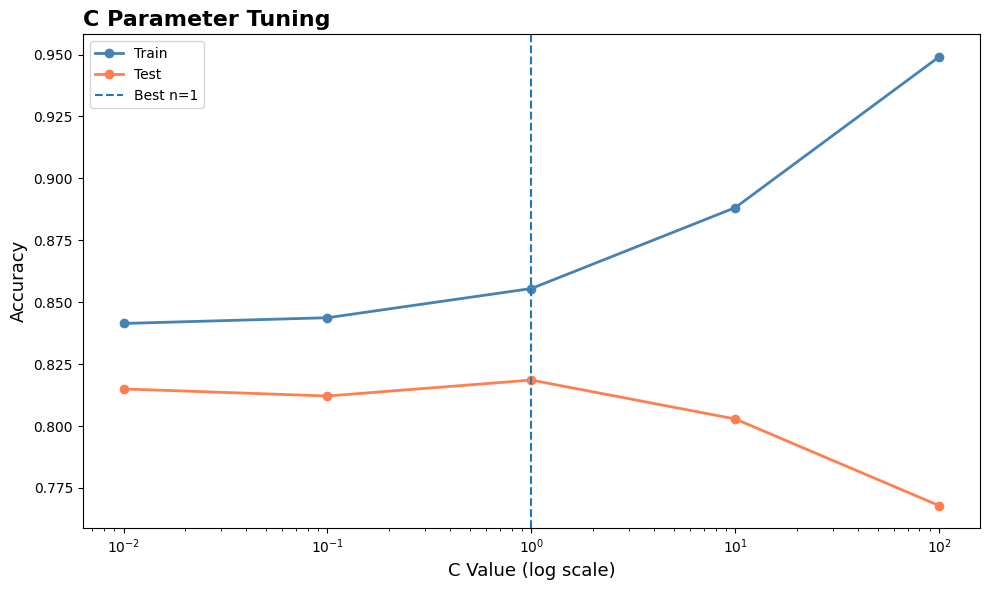

In [ ]:
C_values = [0.01, 0.1, 1, 10, 100]
train_scores = []
test_scores  = []

for c in C_values:
    pipe = Pipeline([
        ('scaler' , StandardScaler()),
        ('svm', SVC(C=c,kernel='rbf',random_state=42,gamma='scale'))
    ])
    pipe.fit(X_train,y_train)
    train_scores.append(accuracy_score(y_train, pipe.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  pipe.predict(X_test)))
    
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_scores, marker='o', label='Train',
         color='steelblue', linewidth=2)
plt.plot(C_values, test_scores,  marker='o', label='Test',
         color='coral', linewidth=2)
plt.xscale('log')
plt.xlabel('C Value (log scale)', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('C Parameter Tuning', fontweight='bold',
          fontsize=16, loc='left')
best_index = np.argmax(test_scores)
best_c = C_values[best_index]
best_score = test_scores[best_index]
plt.axvline(best_c, linestyle='--', label=f'Best c={best_c}')
plt.legend()
plt.tight_layout()
plt.show()
    

## **Model Train**

In [37]:
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('svm',SVC(C=1,probability=True,random_state=42,kernel='rbf',gamma='scale'))
])
pipeline.fit(X_train,y_train)
print("Model trained ✅")

Model trained ✅


## **Evalustion**

In [38]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       699
           1       0.84      0.79      0.81       701

    accuracy                           0.82      1400
   macro avg       0.82      0.82      0.82      1400
weighted avg       0.82      0.82      0.82      1400

Accuracy: 0.8186


## **OverFitting**

In [39]:
train_acc = accuracy_score(y_train, pipeline.predict(X_train))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")

Training Accuracy: 0.8555
Testing Accuracy:  0.8186
Gap:               0.0370


## **Charts**

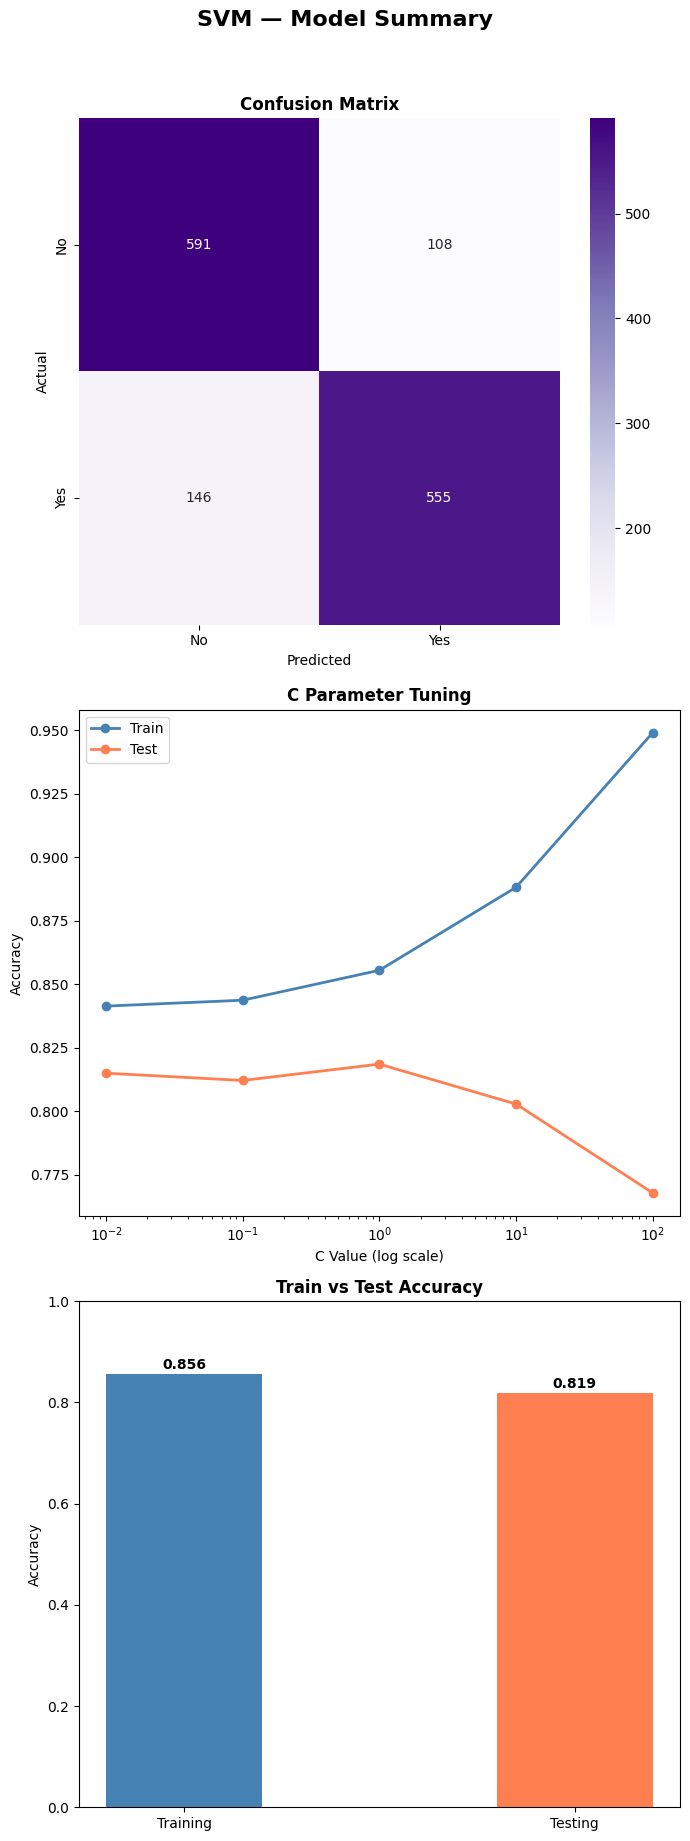

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(7, 18))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — C Parameter Tuning
axes[1].plot(C_values, train_scores, marker='o',
             label='Train', color='steelblue', linewidth=2)
axes[1].plot(C_values, test_scores,  marker='o',
             label='Test',  color='coral',     linewidth=2)
axes[1].set_xscale('log')
axes[1].set_title('C Parameter Tuning', fontweight='bold')
axes[1].set_xlabel('C Value (log scale)')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Plot 3 — Train vs Test Accuracy
labels = ['Training', 'Testing']
scores = [train_acc, test_acc]
colors = ['steelblue', 'coral']
axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Train vs Test Accuracy', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}',
                 ha='center', fontweight='bold')

plt.suptitle('SVM — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()